In [25]:
from pathlib import Path
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [26]:
grid_dir = Path("/home/c4011027/PhD_stuff/SPAMMS/Outputs/results/zetaR_zetaT_inc_vcrit_grid")
line_name = "HEII4200"

def parse_model_info(path):
    params = {}
    with open(path) as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"): continue
            parts = re.split(r"\s*[:=]\s*|\s+", line)
            if len(parts) < 2: continue
            key, val = parts[0].strip(), parts[-1].strip()
            try: params[key] = float(val)
            except ValueError: params[key] = val
    return params

def build_model_grid(grid_dir, line_name="HEII4200"):
    rows = []
    for model_dir in sorted(Path(grid_dir).glob("Model_*")):
        info = model_dir / "model_info.txt"
        if not info.exists(): continue
        params = parse_model_info(info)
        profiles = list(model_dir.glob(f"**/*{line_name}*.txt"))
        if not profiles: continue
        rows.append({
            "model_dir": str(model_dir), "model_name": model_dir.name,
            "inclination": params.get("inclination", np.nan),
            "v_crit_frac": params.get("v_crit_frac", np.nan),
            "sigma_R": params.get("sigma_R", np.nan),
            "sigma_T": params.get("sigma_T", np.nan),
            "profile_file": str(profiles[0])
        })
    return pd.DataFrame(rows).dropna(subset=["profile_file"]).reset_index(drop=True)

df_grid = build_model_grid(grid_dir, line_name)

In [28]:
print(f"Found {len(df_grid)} usable {line_name} profiles.")
print("Inclinations:", np.sort(df_grid["inclination"].unique()))
print("vcrit fracs:", np.sort(df_grid["v_crit_frac"].unique()))
print("sigma_R:", np.sort(df_grid["sigma_R"].unique()))
print("sigma_T:", np.sort(df_grid["sigma_T"].unique()))

Found 900 usable HEII4200 profiles.
Inclinations: [10. 30. 50. 70. 90.]
vcrit fracs: [0.1 0.3 0.5 0.7 0.9]
sigma_R: [100. 150. 200. 250. 300. 350.]
sigma_T: [100. 150. 200. 250. 300. 350.]


In [29]:
def select_truth_model(df_grid, inclination, v_crit_frac, sigma_R, sigma_T):
    m = (np.isclose(df_grid["inclination"], inclination) &
         np.isclose(df_grid["v_crit_frac"], v_crit_frac) &
         np.isclose(df_grid["sigma_R"], sigma_R) &
         np.isclose(df_grid["sigma_T"], sigma_T))
    d = df_grid[m].copy()
    if len(d) != 1: raise ValueError(f"Expected one truth model, found {len(d)}")
    return d.iloc[0]

In [50]:
truth = select_truth_model(df_grid, inclination=70.0, v_crit_frac=0.7, sigma_R=200.0, sigma_T=250.0)
print(truth[["model_name", "inclination", "v_crit_frac", "sigma_R", "sigma_T", "profile_file"]])

model_name                                             Model_0393
inclination                                                  70.0
v_crit_frac                                                   0.7
sigma_R                                                     200.0
sigma_T                                                     250.0
profile_file    /home/c4011027/PhD_stuff/SPAMMS/Outputs/result...
Name: 393, dtype: object


In [51]:
def read_profile(profile_file, fit_window=None):
    data = np.loadtxt(profile_file)
    wave, flux = data[:, 0], data[:, 1]
    if fit_window is not None:
        m = (wave >= fit_window[0]) & (wave <= fit_window[1])
        wave, flux = wave[m], flux[m]
    return wave, flux


def make_fit_grid(df_grid, truth, fix_inclination=True, fix_vcrit=True):
    d = df_grid.copy()
    if fix_inclination: d = d[np.isclose(d["inclination"], truth["inclination"])]
    if fix_vcrit: d = d[np.isclose(d["v_crit_frac"], truth["v_crit_frac"])]
    return d.reset_index(drop=True)


def preload_fit_grid(df_fit, wave_obs, fit_window=None):
    rows, fluxes = [], []
    for _, row in df_fit.iterrows():
        w, f = read_profile(row["profile_file"], fit_window=fit_window)
        fluxes.append(np.interp(wave_obs, w, f))
        rows.append(row)
    return pd.DataFrame(rows).reset_index(drop=True), np.asarray(fluxes)

In [52]:
fit_window = None
# fit_window = (4185, 4215)

df_fit = make_fit_grid(df_grid, truth, fix_inclination=True, fix_vcrit=True)

wave_obs, flux_true = read_profile(truth["profile_file"], fit_window=fit_window)
df_model_rows, model_fluxes = preload_fit_grid(df_fit, wave_obs, fit_window=fit_window)

print(f"Truth model: {truth['model_name']}")
print(f"Number of fitting models: {len(df_fit)}")
print("Inclinations:", np.sort(df_fit["inclination"].unique()))
print("vcrit fracs:", np.sort(df_fit["v_crit_frac"].unique()))
print("sigma_R:", np.sort(df_fit["sigma_R"].unique()))
print("sigma_T:", np.sort(df_fit["sigma_T"].unique()))

Truth model: Model_0393
Number of fitting models: 36
Inclinations: [70.]
vcrit fracs: [0.7]
sigma_R: [100. 150. 200. 250. 300. 350.]
sigma_T: [100. 150. 200. 250. 300. 350.]


In [53]:
def compute_chi_tables(flux_true, model_fluxes, df_model_rows, snr_values, seed=42):
    rng = np.random.default_rng(seed)
    chi_tables, noisy_spectra = {}, {}

    for snr in np.atleast_1d(snr_values):
        sigma = 1.0 / snr
        flux_noisy = flux_true + rng.normal(0.0, sigma, size=flux_true.size)
        residuals = flux_noisy[None, :] - model_fluxes

        chi2 = np.sum((residuals / sigma)**2, axis=1)
        red_chi2 = chi2 / len(flux_true)

        d = df_model_rows.copy()
        d["chi2"], d["red_chi2"] = chi2, red_chi2
        d = d.sort_values("chi2").reset_index(drop=True)

        chi_tables[snr] = d
        noisy_spectra[snr] = flux_noisy

    return chi_tables, noisy_spectra

In [54]:
snr_values = [50, 100, 300]

chi_tables, noisy_spectra = compute_chi_tables(
    flux_true=flux_true,
    model_fluxes=model_fluxes,
    df_model_rows=df_model_rows,
    snr_values=snr_values,
    seed=42
)

for snr in snr_values:
    print(f"\nS/N = {snr}")
    print(chi_tables[snr][["model_name", "inclination", "v_crit_frac", "sigma_R", "sigma_T", "chi2", "red_chi2"]].head(10))


S/N = 50
   model_name  inclination  v_crit_frac  sigma_R  sigma_T          chi2  \
0  Model_0293         70.0          0.7    150.0    350.0  12319.612886   
1  Model_0393         70.0          0.7    200.0    250.0  12322.642425   
2  Model_0368         70.0          0.7    200.0    200.0  12324.905764   
3  Model_0268         70.0          0.7    150.0    300.0  12325.922387   
4  Model_0418         70.0          0.7    200.0    300.0  12328.308635   
5  Model_0518         70.0          0.7    250.0    200.0  12328.344520   
6  Model_0468         70.0          0.7    250.0    100.0  12330.406095   
7  Model_0443         70.0          0.7    200.0    350.0  12331.545851   
8  Model_0493         70.0          0.7    250.0    150.0  12332.803992   
9  Model_0143         70.0          0.7    100.0    350.0  12335.552523   

   red_chi2  
0  1.009804  
1  1.010053  
2  1.010238  
3  1.010322  
4  1.010517  
5  1.010520  
6  1.010689  
7  1.010782  
8  1.010886  
9  1.011111  

S/N = 100

In [55]:
def plot_sigmaR_sigmaT_chimap(chi_tables, truth, snr_values, chi_col="chi2", levels=(2.30, 11.83), cmap="viridis"):
    snr_values = list(np.atleast_1d(snr_values))
    fig, axes = plt.subplots(1, len(snr_values), figsize=(5.4*len(snr_values), 4.8), sharex=True, sharey=True)
    if len(snr_values) == 1: axes = [axes]

    ims = []
    for ax, snr in zip(axes, snr_values):
        d = chi_tables[snr].copy()
        d2 = d.groupby(["sigma_R", "sigma_T"], as_index=False)[chi_col].min()
        d2["delta_chi2"] = d2[chi_col] - d2[chi_col].min()

        sr_vals, st_vals = np.sort(d2["sigma_R"].unique()), np.sort(d2["sigma_T"].unique())
        z = np.full((len(sr_vals), len(st_vals)), np.nan)

        for i, sr in enumerate(sr_vals):
            for j, st in enumerate(st_vals):
                m = d2[np.isclose(d2["sigma_R"], sr) & np.isclose(d2["sigma_T"], st)]
                if len(m): z[i, j] = m["delta_chi2"].values[0]

        im = ax.imshow(z, origin="lower", aspect="auto",
                       extent=[st_vals.min(), st_vals.max(), sr_vals.min(), sr_vals.max()],
                       interpolation="nearest", cmap=cmap)
        ims.append(im)

        finite = z[np.isfinite(z)]
        if finite.size:
            levs = [lv for lv in levels if finite.min() <= lv <= finite.max()]
            if levs:
                ax.contour(st_vals, sr_vals, z, levels=levs,
                           colors=["white" if lv == levels[0] else "red" for lv in levs],
                           linewidths=[1.8]*len(levs))

        best = d.iloc[0]
        ax.scatter(truth["sigma_T"], truth["sigma_R"], marker="o", s=120,
                   facecolors="none", edgecolors="white", linewidths=2.2, label="Truth")
        ax.scatter(best["sigma_T"], best["sigma_R"], marker="x", s=120,
                   color="red", linewidths=2.2, label="Best")

        ax.set_title(rf"S/N = {snr}", fontsize=14)
        ax.set_xlabel(r"$\sigma_T$ [km s$^{-1}$]", fontsize=13)
        ax.tick_params(axis="both", labelsize=11, direction="in", top=True, right=True)

    axes[0].set_ylabel(r"$\sigma_R$ [km s$^{-1}$]", fontsize=13)
    cbar = fig.colorbar(ims[-1], ax=axes, pad=0.02)
    cbar.set_label(r"$\Delta\chi^2$", fontsize=13)
    cbar.ax.tick_params(labelsize=11)

    fig.suptitle(
        rf"$\Delta\chi^2$ landscape in $(\sigma_R,\sigma_T)$",
        fontsize=15
    )
    plt.show()

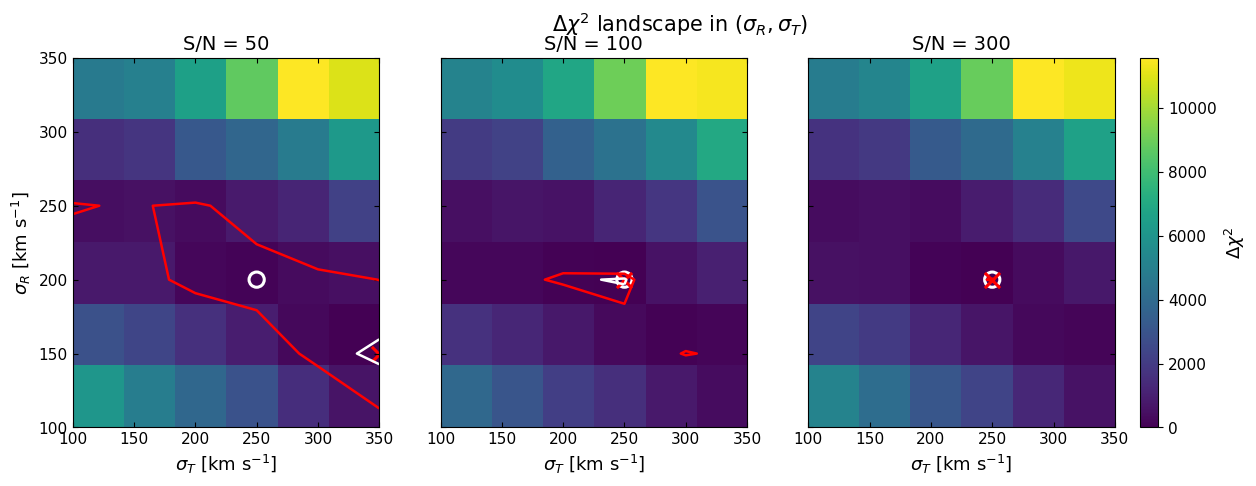

In [56]:
plot_sigmaR_sigmaT_chimap(chi_tables, truth, snr_values)

In [57]:
def plot_1d_chi_landscape(chi_tables, truth, snr_values, param="sigma_R", chi_col="chi2", levels=(1.0, 9.0)):
    snr_values = list(np.atleast_1d(snr_values))
    xlabel = r"$\sigma_R$ [km s$^{-1}$]" if param == "sigma_R" else r"$\sigma_T$ [km s$^{-1}$]"

    fig, axes = plt.subplots(1, len(snr_values), figsize=(5.2*len(snr_values), 4.4), sharey=True)
    if len(snr_values) == 1: axes = [axes]

    for ax, snr in zip(axes, snr_values):
        d = chi_tables[snr].copy()
        dland = d.groupby(param, as_index=False)[chi_col].min().sort_values(param)
        dland["delta_chi2"] = dland[chi_col] - dland[chi_col].min()

        best_val, true_val = d.iloc[0][param], truth[param]

        ax.plot(dland[param], dland["delta_chi2"], marker="o", lw=2.0, color="tab:blue")
        ax.axvline(true_val, color="black", ls="--", lw=1.8, label="Truth")
        ax.axvline(best_val, color="tab:red", ls=":", lw=2.2, label="Best")

        for lv, ls in zip(levels, ["--", ":"]):
            ax.axhline(lv, color="gray", ls=ls, lw=1.1, alpha=0.7)

        ax.set_title(rf"S/N = {snr}", fontsize=14)
        ax.set_xlabel(xlabel, fontsize=13)
        ax.tick_params(axis="both", labelsize=11, direction="in", top=True, right=True)
        ax.legend(fontsize=9, frameon=False)

    axes[0].set_ylabel(r"$\Delta\chi^2$", fontsize=13)
    fig.suptitle(rf"1D $\Delta\chi^2$ landscape for {xlabel}", fontsize=15)
    fig.tight_layout(rect=[0, 0, 1, 0.92])
    plt.show()

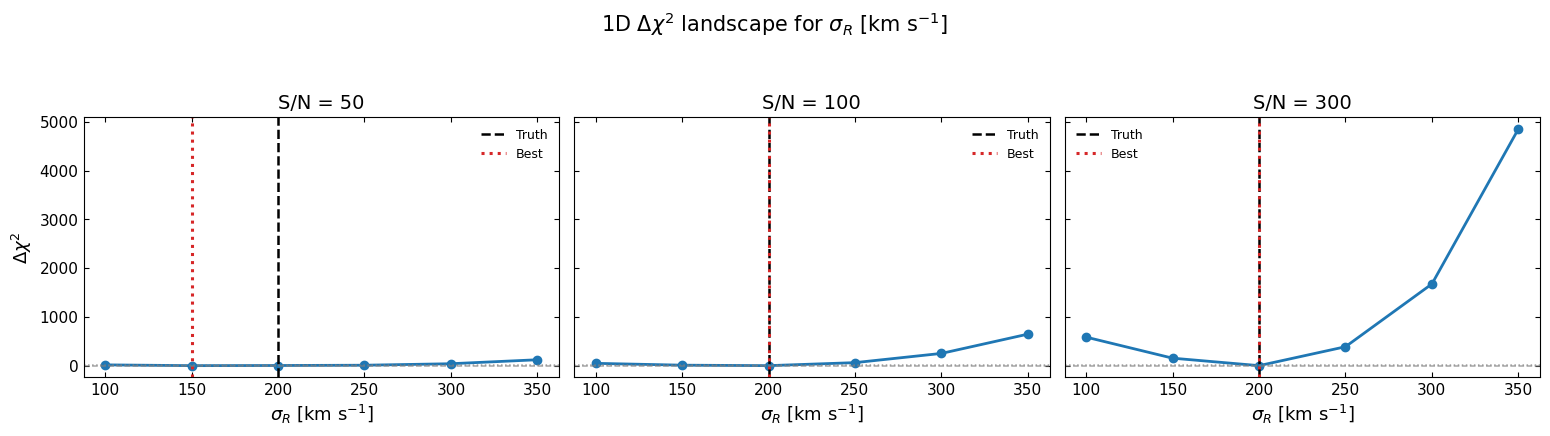

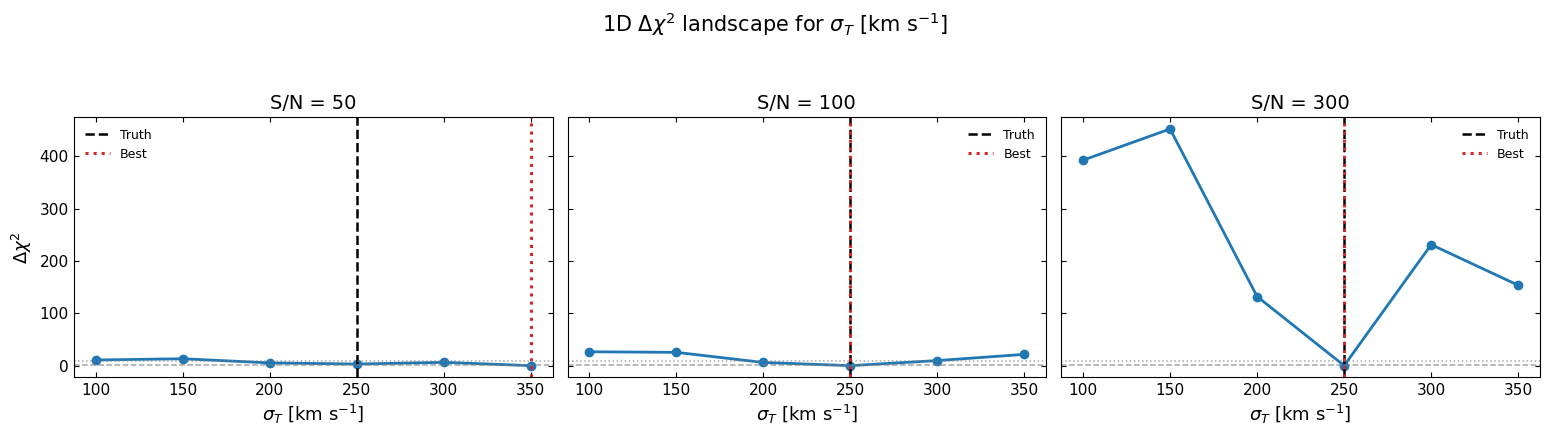

In [58]:
plot_1d_chi_landscape(chi_tables, truth, snr_values, param="sigma_R")
plot_1d_chi_landscape(chi_tables, truth, snr_values, param="sigma_T")